In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import scipy.stats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from autogluon.tabular import TabularPredictor
from BorutaShap import BorutaShap
from lightgbm import LGBMClassifier

In [8]:
X_train = pd.read_csv('data/train.csv')
X_test = pd.read_csv('data/test.csv')
y_train = X_train.pop('Churn') 

In [9]:
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

#### Używanie podzbioru dla szybszych obliczeń - sprawdzamy dodanie których kolumn (interakcji/nowych cech) najbardziej zwiększa roc auc

In [15]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, 
    y_train, 
    train_size=0.30,   
    random_state=42,   
    stratify=y_train   
)

In [16]:
y_sample = y_sample.map({'No': 0, 'Yes': 1})
categorical_cols = X_sample.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
X_cv = X_sample.copy()
X_cv['tenure_safe'] = X_cv['tenure'].replace(0, 0.001)
avg_historical_charge_cv = X_cv['TotalCharges'] / X_cv['tenure_safe']
X_cv['Int_PriceShockRatio'] = X_cv['MonthlyCharges'] / (avg_historical_charge_cv + 0.001)
X_cv['Int_CostPerTenure'] = X_cv['MonthlyCharges'] / X_cv['tenure_safe']
X_cv['Int_ImpliedTenureDiff'] = (X_cv['TotalCharges'] / (X_cv['MonthlyCharges'] + 0.001)) - X_cv['tenure']
X_cv['Int_CumulativeBurden'] = X_cv['TotalCharges'] * X_cv['MonthlyCharges']
base_cat_features = categorical_cols
### WAŻNE: SeniorCitizen jest typu, ale to kategoria
base_cat_features.append('SeniorCitizen')

In [17]:
candidate_numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 
    'Int_PriceShockRatio', 'Int_CostPerTenure', 
    'Int_ImpliedTenureDiff', 'Int_CumulativeBurden'
]

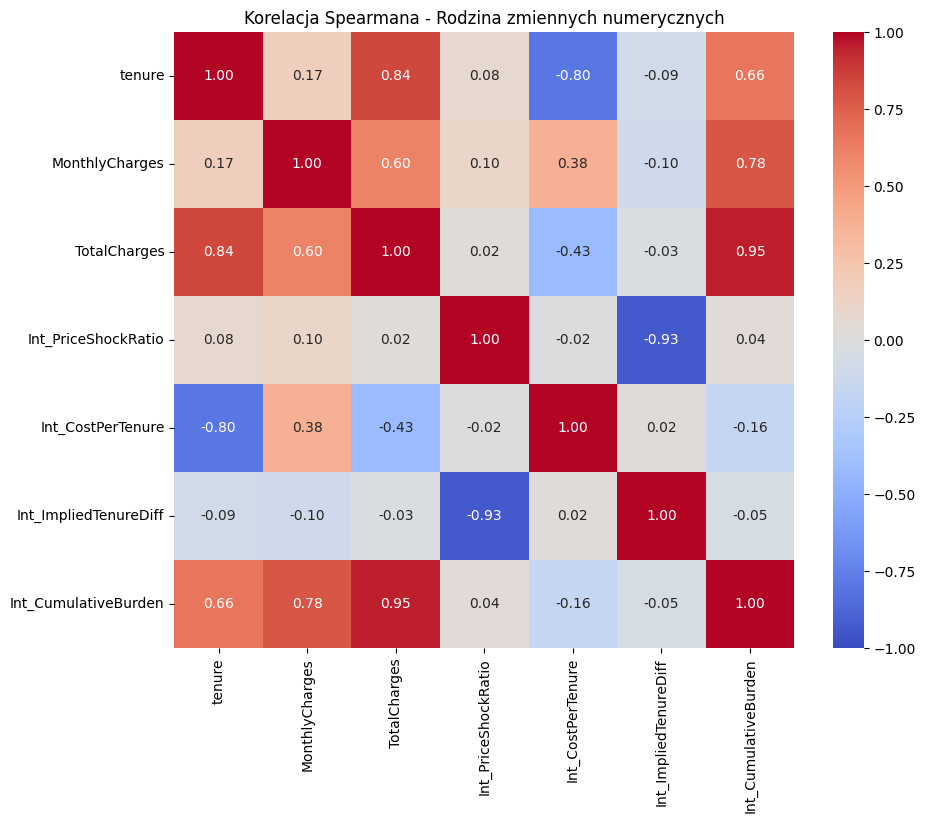

In [18]:
corr_matrix = X_cv[candidate_numeric_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelacja Spearmana - Rodzina zmiennych numerycznych")
plt.show()

In [19]:
def get_cv_score(features_to_test, X_data, y_data):
    X = X_data[base_cat_features + features_to_test]
    y = y_data
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', TargetEncoder(random_state=42), base_cat_features),
            ('num', 'passthrough', features_to_test)
        ]
    )
    
    model = LGBMClassifier(
        n_estimators=100, 
        max_depth=6, 
        num_leaves=31, 
        random_state=42, 
        n_jobs=-1,
        verbose=-1    
    )
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    return np.mean(scores)

print("Rozpoczynam zindywidualizowaną selekcję zmiennych...\n")

best_features = []
best_score = 0.0

for feature in candidate_numeric_features:
    score = get_cv_score([feature], X_cv, y_sample)
    if score > best_score:
        best_score = score
        best_initial_feature = feature

best_features.append(best_initial_feature)
candidate_numeric_features.remove(best_initial_feature)
print(f"Baza: Tylko kategoryczne + '{best_initial_feature}' -> ROC AUC: {best_score:.5f}")
improvement = True
while improvement and candidate_numeric_features:
    improvement = False
    best_step_score = best_score
    best_feature_to_add = None
    
    for feature in candidate_numeric_features:
        current_test_features = best_features + [feature]
        score = get_cv_score(current_test_features, X_cv, y_sample)
        
        if score > best_step_score:
            best_step_score = score
            best_feature_to_add = feature
            improvement = True
            
    if improvement:
        best_features.append(best_feature_to_add)
        candidate_numeric_features.remove(best_feature_to_add)
        best_score = best_step_score
        print(f"Dodano '{best_feature_to_add}' -> Nowy najlepszy ROC AUC: {best_score:.5f}")
    else:
        print("\nŻadna z pozostałych zmiennych nie poprawia już wyniku.")

print("\n--- PODSUMOWANIE ---")
print(f"Optymalny zestaw numeryczny (maksymalizujący ROC AUC): {best_features}")
print(f"Ostateczny wynik OOF ROC AUC: {best_score:.5f}")
print(f"Zmienne odrzucone jako szum/redundantne: {candidate_numeric_features}")

Rozpoczynam zindywidualizowaną selekcję zmiennych...

Baza: Tylko kategoryczne + 'tenure' -> ROC AUC: 0.91258
Dodano 'TotalCharges' -> Nowy najlepszy ROC AUC: 0.91372
Dodano 'Int_PriceShockRatio' -> Nowy najlepszy ROC AUC: 0.91398
Dodano 'Int_CumulativeBurden' -> Nowy najlepszy ROC AUC: 0.91400

Żadna z pozostałych zmiennych nie poprawia już wyniku.

--- PODSUMOWANIE ---
Optymalny zestaw numeryczny (maksymalizujący ROC AUC): ['tenure', 'TotalCharges', 'Int_PriceShockRatio', 'Int_CumulativeBurden']
Ostateczny wynik OOF ROC AUC: 0.91400
Zmienne odrzucone jako szum/redundantne: ['MonthlyCharges', 'Int_CostPerTenure', 'Int_ImpliedTenureDiff']


Wygląda na to, że trzy najlepsze zmienne to CostPerTenure, tenure oraz MonthlyCharges

### Sprawdzenie interakcji cech kategorycznych

#### Ad. 1) Czy dla Streaming Movies/Tv wystarczy dla polepszenia predykcji sama informacja czy nie było internet service

In [20]:
cross_tab = pd.crosstab(X_train['InternetService'], X_train['StreamingTV'])
cross_tab

StreamingTV,No,No internet service,Yes
InternetService,,,
DSL,104608,0,76473
Fiber optic,108558,0,163828
No,0,140727,0


In [21]:
base_cat_features = categorical_cols.copy()
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
cols_to_drop = ['StreamingTV', 'StreamingMovies', 'MultipleLines']
print(f"\n--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: {cols_to_drop} ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_full = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Pełna baza (Wszystkie predyktory) -> ROC AUC: {score_1_full:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_drop]
score_2_dropped = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: {score_2_dropped:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: ['StreamingTV', 'StreamingMovies', 'MultipleLines'] ---
1. Pełna baza (Wszystkie predyktory) -> ROC AUC: 0.91400
2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: 0.91277


#### Widać, że cała wiedza zawarta w StreamingTV jest zawarta w InternetService, ale usunięcie ich zmniejsza ROC AUC

#### Ad. 2) Czy zsumowanie liczby usług będzie lepsze niż trzymanie ich razem?

In [24]:
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
X_cv['Num_Services'] = (X_cv[services_cols] == 'Yes').sum(axis=1)
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in services_cols] 
score_3 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---
1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: 0.91400
2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: 0.91400
3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: 0.91382


#### Zamiana na Num_Services bez zmian

#### Ad. 3) Sprawdzenie czy Partners i Dependants dają lepsze wyniki

In [25]:
family_cols = ['Partner', 'Dependents']
X_cv['FamilySize'] = (X_cv[family_cols] == 'Yes').sum(axis=1)
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały (Brak FamilySize) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"2. Oryginały + FamilySize -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in family_cols] 
score_3 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---
1. Oryginały (Brak FamilySize) -> ROC AUC: 0.91400
2. Oryginały + FamilySize -> ROC AUC: 0.91408
3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: 0.91382


#### Jest postęp
WAŻNE: jeśli zmieniamy jakąś cechę (w zależności od wyników to trzeba ją dodać/odpowiednie usunąć z best_num lub base_cat_features)

In [ ]:
best_num.append('FamilySize')

#### Ad. 4) Phone Service + Internet Service

In [31]:
X_cv['Phone_Internet_Combo'] = X_cv['PhoneService'].astype(str) + "_" + X_cv['InternetService'].astype(str)
cols_to_combine = ['PhoneService', 'InternetService', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Phone_Internet_Combo']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine] + ['Phone_Internet_Combo']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408
2. Oryginały + Combo -> ROC AUC: 0.91396
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91398


#### Bez zmian

#### Ad. 5) Paperless Billing oraz Senior Citizen

In [32]:
X_cv['Paperless_Senior_Combo'] = X_cv['PaperlessBilling'].astype(str) + "_" + X_cv['SeniorCitizen'].astype(str)
cols_to_combine_3 = ['PaperlessBilling', 'SeniorCitizen', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_paperless:.5f}")
base_cat_features = oryginalne_kategorie + ['Paperless_Senior_Combo']
score_2_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_paperless:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_3] + ['Paperless_Senior_Combo']
score_3_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_paperless:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408
2. Oryginały + Combo -> ROC AUC: 0.91406
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91404


#### Bez zmian

#### Ad. 6) Profil płatnika - PaymentMethod + PaperlessBilling

In [33]:
X_cv['Payment_Paperless_Combo'] = X_cv['PaymentMethod'].astype(str) + "_" + X_cv['PaperlessBilling'].astype(str)
cols_to_combine_payment = ['PaymentMethod', 'PaperlessBilling']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_pay:.5f}")
base_cat_features = oryginalne_kategorie + ['Payment_Paperless_Combo']
score_2_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_pay:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_payment] + ['Payment_Paperless_Combo']
score_3_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_pay:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408
2. Oryginały + Combo -> ROC AUC: 0.91400
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91400


Zmienna nic nie wnosi

#### Ad. 7) Samotny Senior

In [34]:
X_cv['Senior_Partner_Combo'] = X_cv['SeniorCitizen'].astype(str) + "_" + X_cv['Partner'].astype(str)
cols_to_combine_senior = ['SeniorCitizen', 'Partner']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_sen:.5f}")
base_cat_features = oryginalne_kategorie + ['Senior_Partner_Combo']
score_2_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_sen:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_senior] + ['Senior_Partner_Combo']
score_3_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_sen:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408
2. Oryginały + Combo -> ROC AUC: 0.91400
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91394


Brak poprawy

#### Binning zmiennej tenure ze zmienną Contract

In [35]:
tree_bin = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_bin.fit(X_cv[['tenure']], y_sample)
thresholds = tree_bin.tree_.threshold
print(thresholds)
splits = [th for th in thresholds if th != -2]
splits.sort()

print(f"Optymalne progi podziału znalezione przez model: {splits}")
opt_przedzialy = [-np.inf] + splits + [np.inf]
opt_etykiety = [f"Bin_{i+1}" for i in range(len(opt_przedzialy) - 1)]
X_cv['tenure_binned_opt'] = pd.cut(X_cv['tenure'], bins=opt_przedzialy, labels=opt_etykiety)
X_cv['Tenure_Contract_Combo_Opt'] = X_cv['tenure_binned_opt'].astype(str) + "_" + X_cv['Contract'].astype(str)
print("\n--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---")
oryginalne_kategorie = base_cat_features.copy()
kolumny_do_wyrzucenia = ['Contract']
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Baza (Oryginalny Contract i tenure) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Tenure_Contract_Combo_Opt']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza + Optymalne Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in kolumny_do_wyrzucenia] + ['Tenure_Contract_Combo_Opt']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

[17.5  1.5 -2.  -2.  42.5 -2.  -2. ]
Optymalne progi podziału znalezione przez model: [np.float64(1.5), np.float64(17.5), np.float64(42.5)]

--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---
1. Baza (Oryginalny Contract i tenure) -> ROC AUC: 0.91408
2. Baza + Optymalne Combo -> ROC AUC: 0.91393
3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: 0.91394


#### Dodanie tej zmiennej zwiększa predykcyjność

In [ ]:
#base_cat_features.append('Tenure_Contract_Combo_Opt')

#### Budowa zbioru danych

In [36]:
final_features = base_cat_features + best_num
X_train_final = X_cv[final_features].copy()
df_train_final = X_train_final.copy()
df_train_final['Churn'] = y_sample.values 
print(f"Ostateczna liczba predyktorów: {X_train_final.shape[1]}")
print(f"Wybrane kolumny:\n{X_train_final.columns.tolist()}")

Ostateczna liczba predyktorów: 21
Wybrane kolumny:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden', 'FamilySize']


#### Pipeline do treningu - autogluon oraz przetworzenie dla całego zbioru danych

In [39]:
def prepare_data_for_autogluon(X_df):
    df = X_df.copy()
    family_cols = ['Partner', 'Dependents']
    df['FamilySize'] = (df[family_cols] == 'Yes').sum(axis=1)
    avg_historical_charge_cv = df['TotalCharges'] / df['tenure'].replace(0, 0.001)
    df['Int_PriceShockRatio'] = df['MonthlyCharges'] / (avg_historical_charge_cv + 0.001)
    df['Int_CumulativeBurden'] = df['TotalCharges'] * df['MonthlyCharges']

    final_cols = [
        'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 
        'SeniorCitizen', 'Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden', 'FamilySize'
    ]
    
    return df[final_cols]

In [40]:
X_train_processed = prepare_data_for_autogluon(X_train)
y_train_mapped = y_train.map({'Yes': 1, 'No': 0})
train_data = X_train_processed.copy()
train_data['Churn'] = y_train_mapped

print(f"Gotowa ramka treningowa: {train_data.shape[0]} wierszy, {train_data.shape[1]} kolumn.")

Gotowa ramka treningowa: 594194 wierszy, 22 kolumn.


In [41]:
label = 'Churn'

In [42]:
X_test_processed = prepare_data_for_autogluon(X_test)
test_data = X_test_processed.copy()
print(f"Gotowa ramka testowa: {test_data.shape[0]} wierszy, {test_data.shape[1]} kolumn.")

Gotowa ramka testowa: 254655 wierszy, 21 kolumn.


In [43]:
predictor = TabularPredictor(
    label=label, 
    eval_metric='roc_auc' 
).fit(
    train_data,
    presets='best_quality',  
    time_limit=600,    
    num_stack_levels=1,    
    excluded_model_types=['KNN'], 
    verbosity=2
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260309_192040"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.8.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.49 GB / 15.70 GB (22.2%)
Disk Space Avail:   6.02 GB / 406.19 GB (1.5%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input dat

[1000]	valid_set's binary_logloss: 0.29926


	Ran out of time, early stopping on iteration 1043. Best iteration is:
	[1025]	valid_set's binary_logloss: 0.299238


[1000]	valid_set's binary_logloss: 0.301807


	Ran out of time, early stopping on iteration 1070. Best iteration is:
	[1060]	valid_set's binary_logloss: 0.301771


...

	Ran out of time, early stopping on iteration 2193. Best iteration is:
	[1691]	valid_set's binary_logloss: 0.299633


[1000]	valid_set's binary_logloss: 0.300264
[2000]	valid_set's binary_logloss: 0.300224
[1000]	valid_set's binary_logloss: 0.301538
[1000]	valid_set's binary_logloss: 0.297922
[1000]	valid_set's binary_logloss: 0.300709
[1000]	valid_set's binary_logloss: 0.299943
[1000]	valid_set's binary_logloss: 0.300077
[2000]	valid_set's binary_logloss: 0.300086
[1000]	valid_set's binary_logloss: 0.299125


	0.915	 = Validation score   (roc_auc)
	175.91s	 = Training   runtime
	9.22s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 101.81s of the 246.09s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=0)
	Ran out of time, early stopping on iteration 979. Best iteration is:
	[740]	valid_set's binary_logloss: 0.298394
	Ran out of time, early stopping on iteration 892. Best iteration is:
	[810]	valid_set's binary_logloss: 0.299584


[1000]	valid_set's binary_logloss: 0.298163


	0.9161	 = Validation score   (roc_auc)
	87.39s	 = Training   runtime
	3.64s	 = Validation runtime
Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 9.62s of the 153.90s of remaining time.
	To force training the model, specify the model hyperparameter "ag.max_memory_usage_ratio" to a larger value (currently 1.0, set to >=1.48 to avoid the error)
		To set the same value for all models, do the following when calling predictor.fit: `predictor.fit(..., ag_args_fit={"ag.max_memory_usage_ratio": VALUE})`
		Setting "ag.max_memory_usage_ratio" to values above 1 may result in out-of-memory errors. You may consider using a machine with more memory as a safer alternative.
	Not enough memory to train RandomForestGini_BAG_L1... Skipping this model.
Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 9.03s of the 153.31s of remaining time.
	To force training the model, specify the model hyperparameter "ag.max_memory_usage_ratio" to a larger value (currently 1.0, set

In [44]:
lb = predictor.leaderboard(extra_info=True)
print(lb[['model', 'score_val', 'stack_level']])

                 model  score_val  stack_level
0  WeightedEnsemble_L3   0.916120            3
1  WeightedEnsemble_L2   0.916112            2
2      LightGBM_BAG_L1   0.916096            1
3      LightGBM_BAG_L2   0.916023            2
4    LightGBMXT_BAG_L2   0.915601            2
5    LightGBMXT_BAG_L1   0.915005            1
6      CatBoost_BAG_L2   0.907392            2


In [45]:
importance = predictor.feature_importance(train_data)
print(importance)

Computing feature importance via permutation shuffling for 21 features using 5000 rows with 5 shuffle sets...
	142.22s	= Expected runtime (28.44s per shuffle set)
	117.29s	= Actual runtime (Completed 5 of 5 shuffle sets)


                      importance    stddev       p_value  n  p99_high  \
Contract                0.065154  0.003351  8.362664e-07  5  0.072053   
tenure                  0.042003  0.003958  9.346954e-06  5  0.050152   
InternetService         0.023875  0.003004  2.943956e-05  5  0.030060   
TotalCharges            0.011507  0.001076  9.074189e-06  5  0.013723   
PaymentMethod           0.006450  0.000906  4.547973e-05  5  0.008316   
Int_PriceShockRatio     0.005808  0.000508  6.944584e-06  5  0.006854   
Int_CumulativeBurden    0.005559  0.001174  2.251909e-04  5  0.007976   
MultipleLines           0.003461  0.000438  3.022642e-05  5  0.004364   
StreamingMovies         0.002439  0.000911  1.957716e-03  5  0.004315   
StreamingTV             0.002269  0.000679  8.587650e-04  5  0.003668   
PaperlessBilling        0.002207  0.000975  3.583474e-03  5  0.004214   
Dependents              0.001472  0.000631  3.225336e-03  5  0.002772   
OnlineSecurity          0.001112  0.000781  1.67312

In [49]:
predictor = TabularPredictor.load("AutogluonModels/ag-20260309_192040")

predictions = predictor.predict_proba(test_data)[1]

df_test_raw = pd.read_csv('data/test.csv')

submission = pd.DataFrame({
    'id': df_test_raw['id'], 
    'Churn': predictions 
})

submission.to_csv('predictions/autogluon_on_LGB.csv', index=False)

print(f"Wygenerowano predykcje dla {submission.shape[0]} wierszy.")
print(submission.head())

Wygenerowano predykcje dla 254655 wierszy.
       id     Churn
0  594194  0.083200
1  594195  0.000699
2  594196  0.107720
3  594197  0.003332
4  594198  0.530043


#### Pomysły na dalsze feature i rozwój:
- Target Encoding, WoE dla zmiennych kategorycznych
- Do sprawdzenia selekcji: permutation importance
- do selekcji na każdym etapie zamiast LightGBM: BorutaSHAP
- Można puścić autogluona na noc
